In [2]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import joblib

model = joblib.load("../models/random_forest_tuned.pkl")

X = pd.read_csv("../data/X_processed.csv")
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.3.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap_values


array([[[ 2.53045250e-03, -2.53045250e-03],
        [ 1.23124020e-01, -1.23124020e-01],
        [-6.20871506e-03,  6.20871506e-03],
        ...,
        [ 8.30177375e-04, -8.30177375e-04],
        [ 7.32632116e-04, -7.32632116e-04],
        [ 5.26714298e-02, -5.26714298e-02]],

       [[-1.12001448e-02,  1.12001448e-02],
        [-6.70426191e-02,  6.70426191e-02],
        [-4.09219675e-02,  4.09219675e-02],
        ...,
        [-4.08512375e-03,  4.08512375e-03],
        [-4.76440775e-03,  4.76440775e-03],
        [-2.31329051e-02,  2.31329051e-02]],

       [[ 5.41903381e-03, -5.41903381e-03],
        [ 5.62071164e-02, -5.62071164e-02],
        [ 1.64952400e-02, -1.64952400e-02],
        ...,
        [ 8.28821904e-04, -8.28821904e-04],
        [ 1.06007731e-02, -1.06007731e-02],
        [-1.18116042e-02,  1.18116042e-02]],

       ...,

       [[ 2.80429564e-03, -2.80429564e-03],
        [-3.99763127e-02,  3.99763127e-02],
        [ 4.44940790e-02, -4.44940790e-02],
        ...,
     

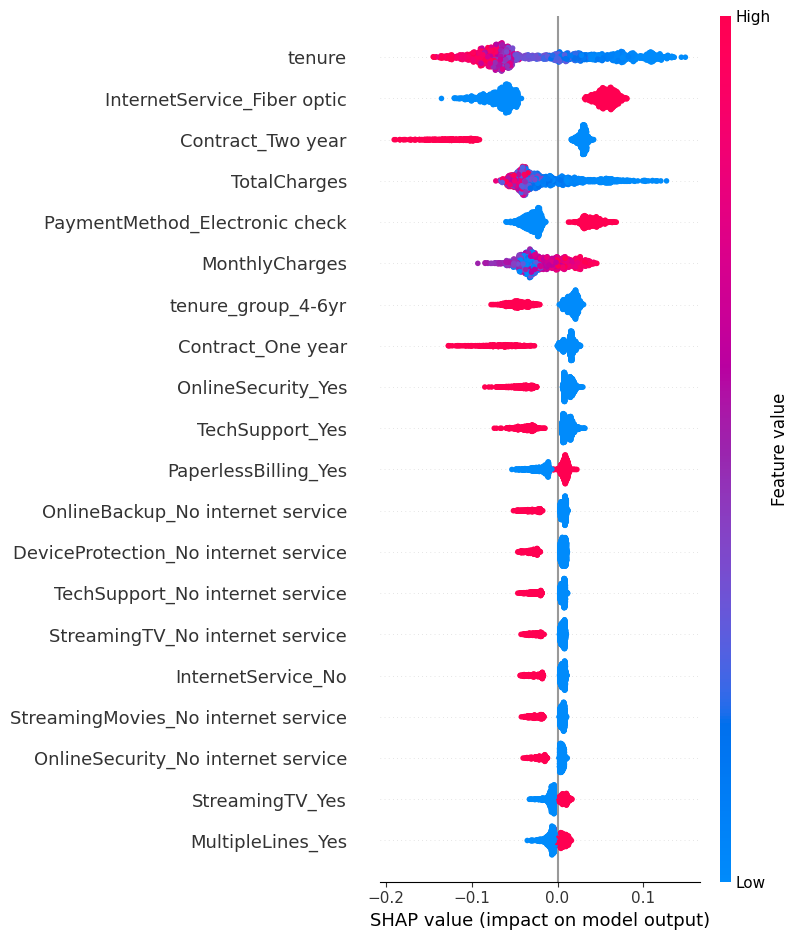

In [11]:
shap.summary_plot(shap_values[:,:,1], X_test)

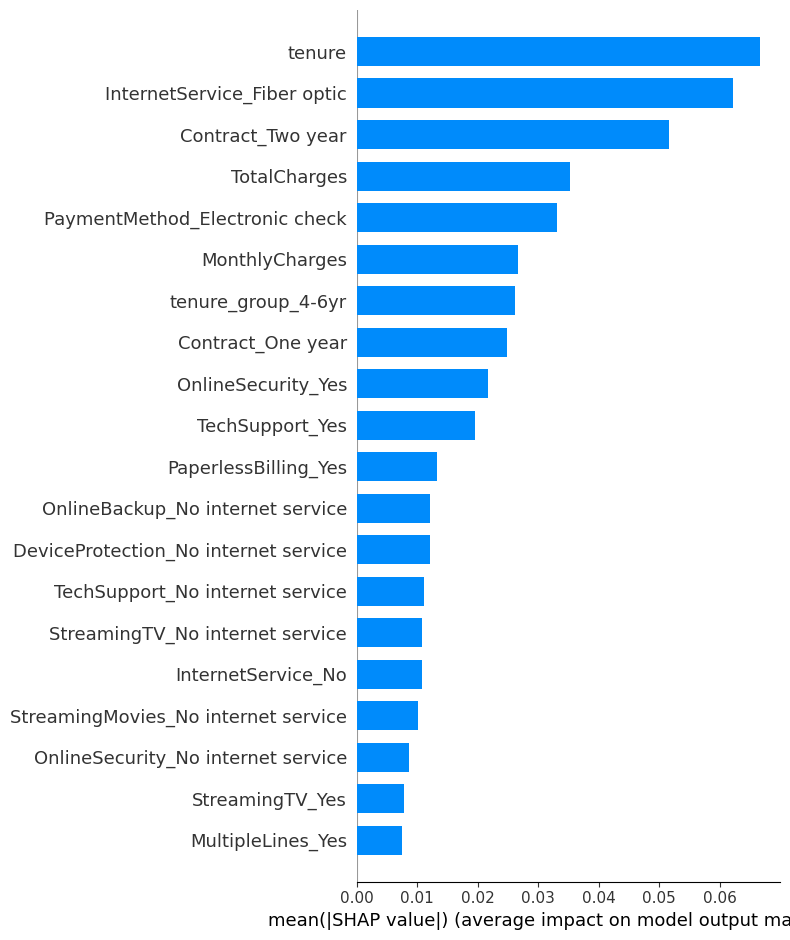

In [13]:
shap.summary_plot(
    shap_values[:,:,1], 
    X_test, 
    plot_type="bar"
)

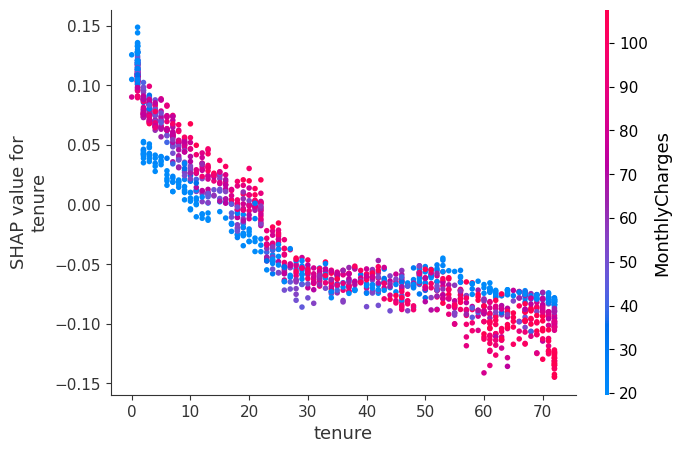

In [ ]:
shap.dependence_plot(
    "tenure",
    shap_values[:,:,1],
    X_test
)